In [1]:
library(edgeR)
library(csaw)
library(Rsamtools)
library(ggplot2)


Loading required package: limma



Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading 

In [2]:
peak.df <- read.table('/media/protein/fy2306/projects/base_editing/data/MYC-ChIP-20260721-bl/peaks/D11_pool_equal_depth/D11_pool_equal_depth_peaks.narrowPeak', sep='\t', header=FALSE)
colnames(peak.df) <- c('contig', 'start', 'stop', 'peak_name', 'score', 'strand', 'signal', 'logP', 'logQ', 'summit')
peak.df$peak_id <- peak.df$peak_name
standard.chr <- paste0("chr", c(1:22, "X", "Y"))
peak.df <- peak.df[peak.df$contig %in% standard.chr, ]
head(peak.df)

,contig,start,stop,peak_name,score,strand,signal,logP,logQ,summit,peak_id
,<chr>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1145,chr1,115609,115766,D11_pool_equal_depth_peak_1145,42,.,2.17643,4.22727,1.197430,131,D11_pool_equal_depth_peak_1145
1146,chr1,269191,269476,D11_pool_equal_depth_peak_1146,13,.,1.50618,1.35906,0.000000,38,D11_pool_equal_depth_peak_1146
1147,chr1,605342,605627,D11_pool_equal_depth_peak_1147,62,.,2.99705,6.21076,2.713900,51,D11_pool_equal_depth_peak_1147
1148,chr1,778421,778962,D11_pool_equal_depth_peak_1148,107,.,3.65788,10.71650,6.749320,117,D11_pool_equal_depth_peak_1148
1149,chr1,827295,827505,D11_pool_equal_depth_peak_1149,32,.,2.21521,3.24056,0.605519,82,D11_pool_equal_depth_peak_1149
1150,chr1,831329,831511,D11_pool_equal_depth_peak_1150,32,.,2.21521,3.24056,0.605519,61,D11_pool_equal_depth_peak_1150


In [3]:
stat.df <- read.csv('/media/protein/sequencing_data2/MYC-ChIP-20260721/analysis/D11_quantifications.stats.csv')
stat.df <- stat.df[stat.df$contig_name == 'chr1',]  # only need one row per sample for general stats
stat.df$treatment <- sapply(stat.df$name, function(nm) {
    if ( grepl('SCC2', nm )) {
        'SCC2'
    } else if (grepl('SCC5', nm)) {
        'SCC5'
    } else {
        'CTL'
    }
})
head(stat.df)


,name,total_reads,spikein_reads,target_reads,read_normalization,total_fragments,spikein_fragments,target_fragments,normalization_factor,fragments_in_peak,pct_fragments_in_peak,contig_name,contig_reads,contig_fragments,is_spike_in,duplication,treatment
,<chr>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>
1,D11_ctl_R1,31345594,7399,31338195,4.054602,30088933,7399,30081534,4.054602,3169286,10.5,chr1,2932004,2818064,False,3.9,CTL
2065,D11_ctl_R2,35570645,4068,35566577,7.374631,34087005,4068,34082937,7.374631,3711635,10.9,chr1,3324138,3188934,False,4.1,CTL
4129,D11_SCC2_R1,24506596,3455,24503141,8.683068,23791294,3455,23787839,8.683068,2451716,10.3,chr1,2310657,2246253,False,2.8,SCC2
6193,D11_SCC2_R2,23445449,2184,23443265,13.736264,22754886,2184,22752702,13.736264,2403902,10.6,chr1,2235059,2170683,False,2.9,SCC2
8257,D11_SCC5_R1,27471121,1059,27470062,28.328612,26851460,1059,26850401,28.328612,2890489,10.8,chr1,2612166,2554807,False,2.2,SCC5
10321,D11_SCC5_R2,28517384,1814,28515570,16.538037,27538831,1814,27537017,16.538037,3066442,11.1,chr1,2687584,2596876,False,3.4,SCC5


In [4]:
count.df <- read.csv('/media/protein/fy2306/projects/base_editing/data/MYC-ChIP-20260721-bl/peak_fragment_counts/D11_pool_equal_depth_peaks_fragment_counts.tsv', sep='\t')
count.df <- count.df[count.df$peak_id %in% peak.df$peak_id, ]
rownames(count.df) <- count.df$peak_id
count.df <- count.df[,grep('^D11_', colnames(count.df))]
head(count.df)

,D11_ctl_R1,D11_ctl_R2,D11_SCC2_R1,D11_SCC2_R2,D11_SCC5_R1,D11_SCC5_R2
,<int>,<int>,<int>,<int>,<int>,<int>
D11_pool_equal_depth_peak_1145,3,9,5,3,7,9
D11_pool_equal_depth_peak_1146,7,4,5,6,4,3
D11_pool_equal_depth_peak_1147,6,11,2,5,12,8
D11_pool_equal_depth_peak_1148,20,26,14,14,11,21
D11_pool_equal_depth_peak_1149,3,4,4,4,8,6
D11_pool_equal_depth_peak_1150,9,7,0,6,7,0


In [5]:
count.meta <- peak.df[,c('peak_id', 'peak_name', 'score', 'logP')]
count.meta$coverage <- rowSums(count.df)
head(count.meta)

,peak_id,peak_name,score,logP,coverage
,<chr>,<chr>,<int>,<dbl>,<dbl>
1145,D11_pool_equal_depth_peak_1145,D11_pool_equal_depth_peak_1145,42,4.22727,36
1146,D11_pool_equal_depth_peak_1146,D11_pool_equal_depth_peak_1146,13,1.35906,29
1147,D11_pool_equal_depth_peak_1147,D11_pool_equal_depth_peak_1147,62,6.21076,44
1148,D11_pool_equal_depth_peak_1148,D11_pool_equal_depth_peak_1148,107,10.71650,106
1149,D11_pool_equal_depth_peak_1149,D11_pool_equal_depth_peak_1149,32,3.24056,29
1150,D11_pool_equal_depth_peak_1150,D11_pool_equal_depth_peak_1150,32,3.24056,29


In [6]:
## edgeR pipeline with csaw TMM normalization from 10 kbp genomic bins
## Reference: csaw Book Section 5.2, Eliminating composition biases
init.peak.pvalue.cutoff <- 0.15
init.coverage.cutoff <- 15

want.peaks <- subset(count.meta, coverage >= init.coverage.cutoff)
want.peaks <- subset(want.peaks, logP >= -log10(init.peak.pvalue.cutoff))

filtered.counts <- subset(count.df, rownames(count.df) %in% want.peaks$peak_id)

print(dim(want.peaks))
print(dim(filtered.counts))

sample.names <- colnames(filtered.counts)
stat.df <- stat.df[match(sample.names, stat.df$name),]
stopifnot(!any(is.na(stat.df$name)))
stopifnot(identical(sample.names, stat.df$name))

# csaw normalization
# https://bioconductor.org/books/3.13/csawBook/chap-norm.html
bam.dir <- '/media/protein/fy2306/projects/base_editing/data/MYC-ChIP-20260721-bl/bigwigs/tmp'
bam.files <- file.path(bam.dir, paste0(sample.names, '.IP.human.filteredbl.bam'))
names(bam.files) <- sample.names
stopifnot(all(file.exists(bam.files)))
stopifnot(all(file.exists(paste0(bam.files, '.bai'))))

param <- readParam(pe="both", max.frag = 400, restrict = standard.chr)
binned <- windowCounts(bam.files, bin=TRUE, width=10000, param=param)
csaw.norm.factors <- normFactors(binned, se.out=FALSE)
names(csaw.norm.factors) <- sample.names

csaw.lib.size <- binned$totals
names(csaw.lib.size) <- sample.names

[1] 363063      5
[1] 363063      6


In [7]:
dge <- DGEList(counts=filtered.counts, group=stat.df$treatment, lib.size=csaw.lib.size)
dge$samples$norm.factors <- csaw.norm.factors

# To keep using edgeR's original peak-count library sizes instead of csaw BAM totals,
# replace the two lines above with:
# dge <- DGEList(counts=filtered.counts, group=stat.df$treatment)
# dge$samples$norm.factors <- csaw.norm.factors

csaw.lib.size.df <- data.frame(
    sample=sample.names,
    treatment=stat.df$treatment,
    csaw_lib_size=csaw.lib.size,
    csaw_norm_factor=csaw.norm.factors,
    effective_lib_size=csaw.lib.size * csaw.norm.factors,
    row.names=NULL
)
write.table(
    csaw.lib.size.df,
    file=file.path(bam.dir, 'D11_csaw_library_sizes.nobl.tsv'),
    sep='\t',
    quote=FALSE,
    row.names=FALSE
)
csaw.lib.size.df


design <- model.matrix(~ 0 + treatment, data=stat.df)

contrasts <- makeContrasts(
  SCC2_vs_CTL = treatmentSCC2 - treatmentCTL,
  SCC5_vs_CTL = treatmentSCC5 - treatmentCTL,
  levels = design
)


dge <- estimateDisp(dge, design)
fit <- glmQLFit(dge, design)

scc2.res <- glmQLFTest(fit, contrast=contrasts[,'SCC2_vs_CTL'])
scc5.res <- glmQLFTest(fit, contrast=contrasts[,'SCC5_vs_CTL'])

scc2.de <- topTags(scc2.res, n=Inf)$table
scc5.de <- topTags(scc5.res, n=Inf)$table

print(dim(scc2.de))
head(scc2.de)


sample,treatment,csaw_lib_size,csaw_norm_factor,effective_lib_size
<chr>,<chr>,<int>,<dbl>,<dbl>
D11_ctl_R1,CTL,27496310,0.9938921,27328365
D11_ctl_R2,CTL,31525590,0.9969202,31428498
D11_SCC2_R1,SCC2,22047596,1.0028404,22110220
D11_SCC2_R2,SCC2,21166808,1.0062671,21299463
D11_SCC5_R1,SCC5,24975782,1.0011674,25004938
D11_SCC5_R2,SCC5,25891891,0.9989611,25864992


[1] 363063      5


,logFC,logCPM,F,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
D11_pool_equal_depth_peak_239311,-1.396048,1.2662876,27.55424,2.655487e-07,0.06609456
D11_pool_equal_depth_peak_241259,-1.732418,0.2710639,26.89644,3.640941e-07,0.06609456
D11_pool_equal_depth_peak_242859,-1.371959,1.1631542,24.29657,1.277600e-06,0.09081188
D11_pool_equal_depth_peak_232229,-2.003148,-0.2319616,23.94783,1.513454e-06,0.09081188
D11_pool_equal_depth_peak_48448,6.061680,-2.0847035,23.47217,1.909744e-06,0.09081188
D11_pool_equal_depth_peak_138681,2.992028,-1.1439956,23.19737,2.180410e-06,0.09081188


In [8]:
scc2.de$peak_id <- rownames(scc2.de)
scc5.de$peak_id <- rownames(scc5.de)
scc2.de <- merge(scc2.de, count.meta, by='peak_id', all.x=TRUE, sort=TRUE)
scc5.de <- merge(scc5.de, count.meta, by='peak_id', all.x=TRUE, sort=TRUE)
cn <- colnames(scc2.de)
cn[8] <- 'MACS.score'
cn[9] <- 'MACS.logP'
colnames(scc2.de) <- cn
colnames(scc5.de) <- cn
head(scc2.de)
head(scc5.de)

,peak_id,logFC,logCPM,F,PValue,FDR,peak_name,MACS.score,MACS.logP,coverage
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,D11_pool_equal_depth_peak_10000,-0.3834098,-1.280535,0.5884618,0.4435320,0.9443209,D11_pool_equal_depth_peak_10000,24,2.42550,51
2,D11_pool_equal_depth_peak_100000,0.3048804,-1.642652,0.2603704,0.6101877,0.9593998,D11_pool_equal_depth_peak_100000,36,3.68342,37
3,D11_pool_equal_depth_peak_100001,0.9718964,-2.212482,1.2017720,0.2737215,0.8774174,D11_pool_equal_depth_peak_100001,13,1.39822,21
4,D11_pool_equal_depth_peak_100002,0.9882773,-2.127575,1.8174973,0.1784839,0.8393806,D11_pool_equal_depth_peak_100002,24,2.42550,23
5,D11_pool_equal_depth_peak_100003,0.6637898,-1.864211,1.2753271,0.2595435,0.8774174,D11_pool_equal_depth_peak_100003,31,3.19459,30
6,D11_pool_equal_depth_peak_100004,0.4235927,-2.009130,0.3583436,0.5498151,0.9571778,D11_pool_equal_depth_peak_100004,20,2.05570,26


,peak_id,logFC,logCPM,F,PValue,FDR,peak_name,MACS.score,MACS.logP,coverage
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,D11_pool_equal_depth_peak_10000,-0.4047369,-1.280535,0.7105720,0.39982999,0.8974750,D11_pool_equal_depth_peak_10000,24,2.42550,51
2,D11_pool_equal_depth_peak_100000,0.4217817,-1.642652,0.5628245,0.45362877,0.8974750,D11_pool_equal_depth_peak_100000,36,3.68342,37
3,D11_pool_equal_depth_peak_100001,1.5990418,-2.212482,4.3279836,0.03821767,0.7391412,D11_pool_equal_depth_peak_100001,13,1.39822,21
4,D11_pool_equal_depth_peak_100002,0.5999230,-2.127575,0.6354121,0.42591781,0.8974750,D11_pool_equal_depth_peak_100002,24,2.42550,23
5,D11_pool_equal_depth_peak_100003,-0.6456523,-1.864211,0.8404825,0.35989045,0.8944718,D11_pool_equal_depth_peak_100003,31,3.19459,30
6,D11_pool_equal_depth_peak_100004,0.5143727,-2.009130,0.5913641,0.44241111,0.8974750,D11_pool_equal_depth_peak_100004,20,2.05570,26


In [9]:
## combine the results for plotting

scc2.de$Contrast <- 'SCC2_vs_CTL'
scc5.de$Contrast <- 'SCC5_vs_CTL'

dat.de <- rbind(scc5.de, scc2.de)
write.table(dat.de, '/media/scratch/fy2306/projects/base_editing/results/ChIP-Seq/D11_all_contrasts.nobl.tsv', row.names=FALSE, sep='\t', quote=FALSE)

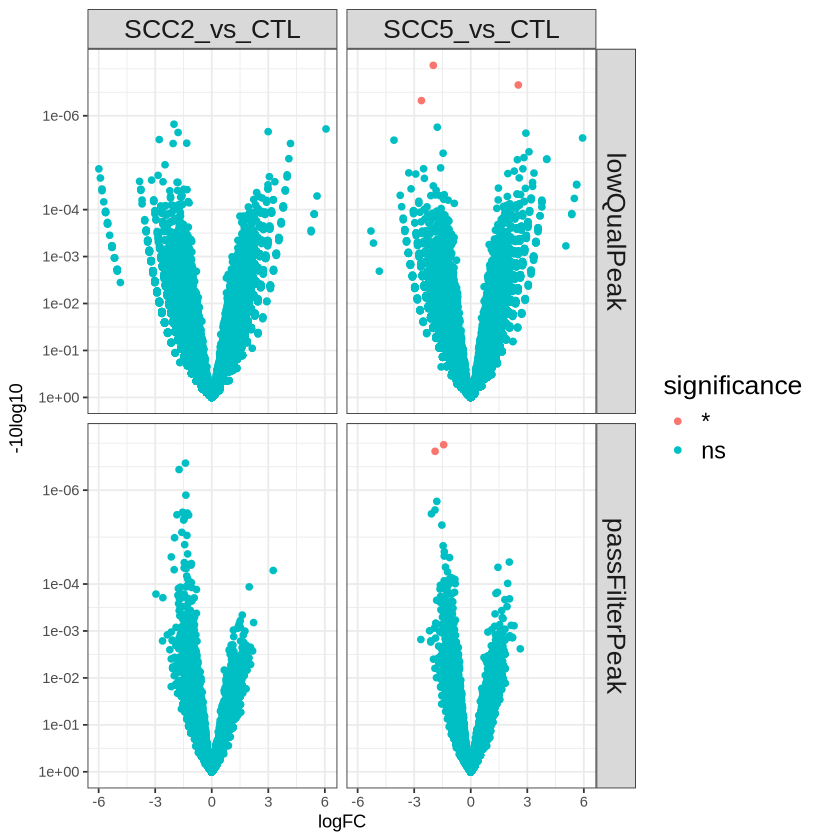

In [10]:
# volcano plot to show the negative shift
library(scales)

neg10log10 <- trans_new(
  "neg10log10",
  transform = function(x) -10*log10(x),
  inverse = function(x) 10^(-x/10)
)

dat.de$filter <- ifelse(dat.de$coverage >= 30 & dat.de$MACS.logP >= -log10(1e-05), 'passFilterPeak', 'lowQualPeak')
dat.de$significance <- ifelse(dat.de$FDR < 0.001, '***', ifelse(dat.de$FDR < 0.01, '**', ifelse(dat.de$FDR < 0.05, '*', 'ns')))
dat.de$significance[is.na(dat.de$significance)] <- 'filtered'
ggplot(dat.de) + geom_point(aes(x=logFC, y=PValue, color=significance)) + scale_y_continuous(trans = neg10log10, name = "-10log10", breaks=c(1, 0.1, 0.01, 0.001, 1e-4, 1e-6, 1e-8)) + 
  facet_grid(filter ~ Contrast) + theme_bw() + theme(strip.text=element_text(size=16), legend.text=element_text(size=14), legend.title=element_text(size=16))

Contrast_group,median_logFC,n,p.value,cdf_at_zero,label,y
<chr>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>
SCC2,-0.07855679,19682,9.642415e-84,0.5652881,median = -0.079 Wilcoxon p = 9.64e-84,0.8153452
SCC5,-0.06890139,19682,3.163358e-60,0.5549233,median = -0.069 Wilcoxon p = 3.16e-60,0.7647400


Warning message:
“Removed 1950 rows containing non-finite outside the scale range
(`stat_density()`).”


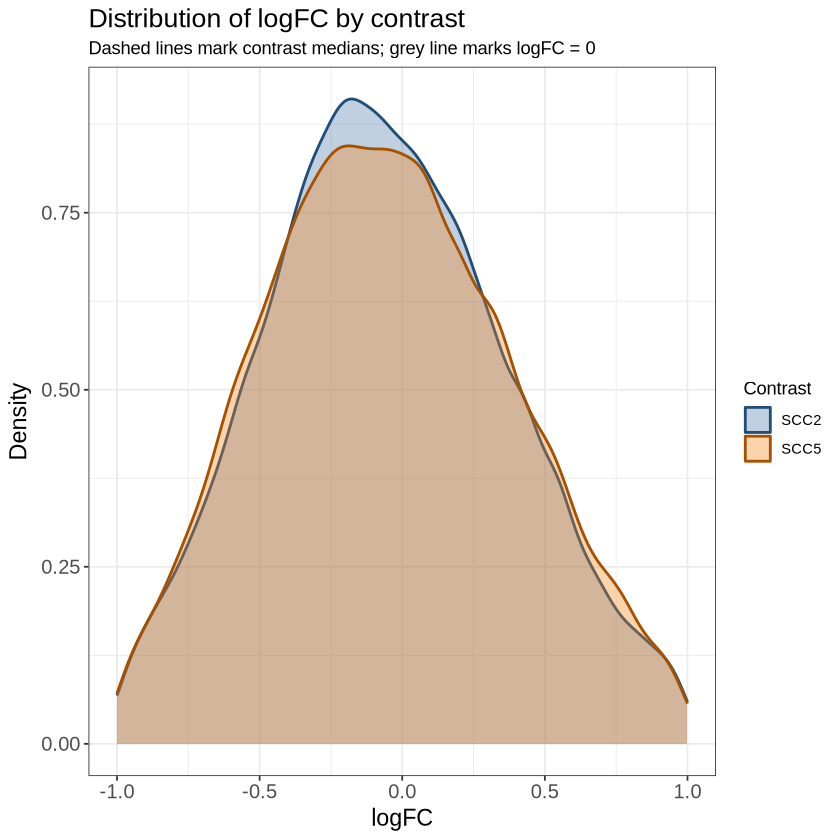

In [11]:
## plot logFC density and test whether the distribution is centered at zero

logfc.df <- subset(dat.de, is.finite(logFC) & !is.na(Contrast) & coverage >= 30 & MACS.logP >= -log10(1e-05))
logfc.df$Contrast_group <- factor(ifelse(grepl("SCC5", logfc.df$Contrast), "SCC5", "SCC2"), levels = c("SCC2", "SCC5"))

logfc.summary <- do.call(rbind, lapply(split(logfc.df$logFC, logfc.df$Contrast_group), function(x) {
  wt <- wilcox.test(x, mu = 0, alternative = "less", exact = FALSE)
  data.frame(
    median_logFC = median(x),
    n = length(x),
    p.value = wt$p.value,
	cdf_at_zero = mean(x <= 0)
  )
} ))
logfc.summary$Contrast_group <- rownames(logfc.summary)
rownames(logfc.summary) <- NULL
logfc.summary$label <- sprintf("median = %.3f\nWilcoxon p = %.2e", logfc.summary$median_logFC, logfc.summary$p.value)

density.max <- do.call(rbind, lapply(split(logfc.df, logfc.df$Contrast_group), function(d) {
  den <- density(d$logFC, na.rm = TRUE)
  data.frame(Contrast_group = d$Contrast_group[1], y = max(den$y) * 0.95)
} ))
logfc.summary <- merge(logfc.summary, density.max, by = "Contrast_group", all.x = TRUE)

logfc.summary

ggplot(logfc.df, aes(x = logFC, fill = Contrast_group, color = Contrast_group, group = Contrast_group)) +
  geom_density(alpha = 0.35, linewidth = 0.8) +
  # geom_vline(xintercept = 0, color = "grey45", linewidth = 0.5) +
  # geom_vline(data = logfc.summary, aes(xintercept = median_logFC, color = Contrast_group), linetype = "dashed", linewidth = 0.8) +
  # geom_text(data = logfc.summary, aes(x = median_logFC, y = y, label = label), inherit.aes = FALSE, angle = 90, vjust = -0.4, hjust = 1, color = "#D55E00", size = 4) +
  scale_fill_manual(values = c("SCC2" = "#4C78A8", "SCC5" = "#F58518"), name = "Contrast") +
  scale_color_manual(values = c("SCC2" = "#1F4E79", "SCC5" = "#A65100"), name = "Contrast") +
  xlim(-1, 1) +
  labs(x = "logFC", y = "Density", title = "Distribution of logFC by contrast", subtitle = "Dashed lines mark contrast medians; grey line marks logFC = 0") +
  theme_bw() +
  theme(strip.text = element_text(size = 16), plot.title = element_text(size = 16), axis.text = element_text(size = 12), axis.title = element_text(size = 14))